# **Diplomado IA: Inteligencia Artificial**.
## Práctico 25 - Repaso Aplicado: Recomendación usando texto e Imágenes
---
---

**Profesores:**
- Julio Hurtado
- Felipe del Río


---
---


In [2]:
Nombre_alumno = "Vicente Zapata" #@param {type:"string"}


# Agenda

## Práctico 25 - Repaso Aplicado: Recomendación usando texto e Imágenes

<!-- Agenda:
 * Problema
 * Preparación
 * Entrenamiento
 * Recomendación -->

Problema

Preparación

> Datos

> Instalación de librerias

Entrenamiento

> Dataset

> Funciones de Entrenamiento

> Funciones para mostrar resultados

> Modelo

> Entrenamiento

Recomendación

> Obtención de Descriptores

> Encontrar similares

> Recomendación

> Metricas de Comparación




> Indented block



# Objetivo del Laboratorio

Una parte importante para consolidar nuevos conocimientos es ponerlos en práctica. Después de algunas clases donde hemos visto varios métodos y algoritmos diferentes es bueno tomar una pausa para poder aplicar estos conocimientos.

En este laboratorio los aplicaremos a un ejemplo más real que los que hemos visto en laboratorios anteriores. El objetivo es corroborar el entendimiento de los conceptos claves, y que después podremos ser capaces de aplicarlos en diferentes problemas que nos podemos encontrar en la vida real.


## Problema

En este laboratorio aplicaremos los conocimientos vistos en las clases anteriores para entrenar un modelo que pueda recomendar contenido a un usuario de una red social, en base a sus interacciones pasadas.

En esta red social, una interacción está conformada por una imagen y un comentario, escrito por un usuario. El objetivo es generar una reacción en los usuarios, por lo que debemos recomendar o mostrarle imágenes de otros usuarios que tienen imágenes con textos similares. Por esta razón, tenemos que tener acceso tanto a las imágenes como al texto escrito por los usuarios para poder encontrar recomendaciones que causen un accionar en el usuario.


## Disclaimer

Existen muchas formas de resolver este problema. El objetivo de este laboratorio no es encontrar la mejor forma de resolver el problema, sino que aprender a plantear un problema real, viendo alternativas y complejidades que puedan ir apareciendo.





# Preparación
## Datos

Los datos son una de las partes más importantes al momento de entrenar modelos de aprendizaje. Si los datos no representan el problema que queremos resolver es muy difícil que nuestro modelo pueda encontrar una solución adecuada. De ahí viene la famosa expresión **"garbage in, garbage out"**.

En esta oportunidad utilizaremos un dataset abierto creado a partir de la red social **Pinterest**. Este dataset nos entrega imágenes y un comentario creado por un usuario. Por razones de *copyright* no tenemos acceso a las imágenes mismas, ya que esto trasgredería los términos y condiciones de esta red social. Para compartir las imagenes, esta base de datos comparte los descriptores de estas, encontrados con un modelo pre-entrenados sobre Imagenet.

Cada elemento de nuestro dataset está conformado por un par imagen-texto asociado a un usuario. Dado esto, definiremos como nuestra tarea, clasificar a qué usuario pertenece cada par imagen-texto del dataset.



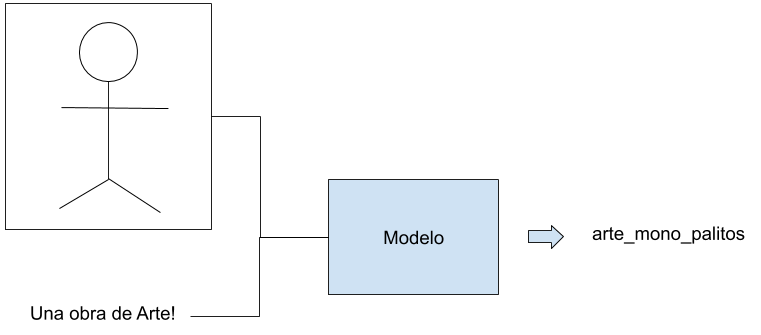

Podemos ver el modelo dividido de dos formas.

1.   Agrupar usuarios dependiendo de sus gustos
2.   Agrupar gustos dependiendo de los usuarios

Queremos que usuarios con gustos similares esten cercanos en el plano, y tambien que grupo de imagenes-texto similares entre ellos tambien esten cercanos.


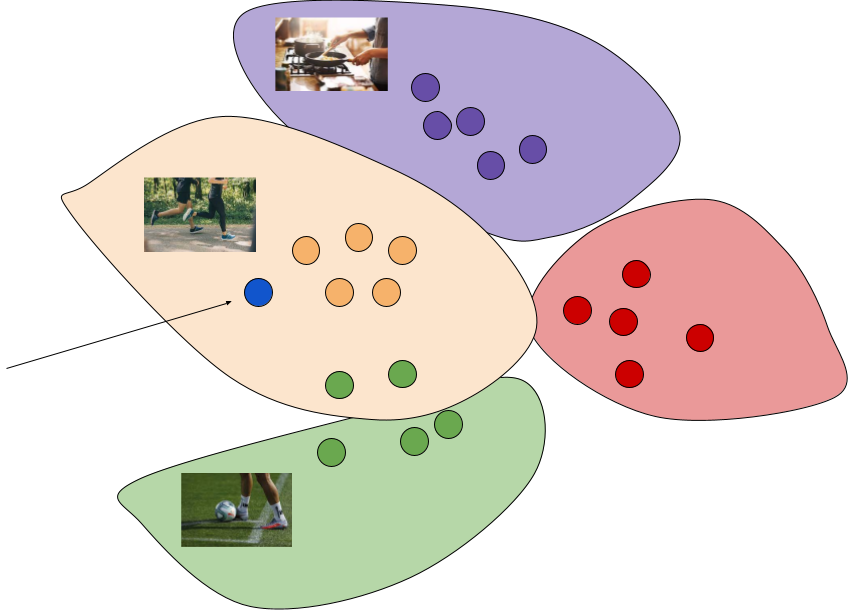

Para poder comenzar, lo primero que debemos hacer es descargar y descomprimir los archivos utilizando los siguientes comandos:

In [3]:
!pip3 install -q --upgrade gdown

In [4]:
!gdown --no-cookies --id 16qaJyW-eE5Ha0ynAS9unolLageB-yiFI

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=16qaJyW-eE5Ha0ynAS9unolLageB-yiFI
From (redirected): https://drive.google.com/uc?id=16qaJyW-eE5Ha0ynAS9unolLageB-yiFI&confirm=t&uuid=4810f351-7ea4-45cc-ba1a-eba148206623
To: /content/fs4k2zc5j5-3.zip
100% 2.16G/2.16G [00:14<00:00, 152MB/s] 


In [5]:
!yes | unzip fs4k2zc5j5-3.zip

Archive:  fs4k2zc5j5-3.zip
  inflating: text_train.txt          
  inflating: text_test.txt           
  inflating: imag_val.txt            
  inflating: val_test_users.txt      
  inflating: images.rar              
  inflating: imag_train.txt          
  inflating: text_val.txt            
  inflating: train_users.txt         
  inflating: imag_test.txt           


In [6]:
!mv imag_train.txt imag_train2.txt
!gdown --id 1Udr59p9vqbUrou2XBx1Dc96v0JcdGzPw

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Udr59p9vqbUrou2XBx1Dc96v0JcdGzPw
From (redirected): https://drive.google.com/uc?id=1Udr59p9vqbUrou2XBx1Dc96v0JcdGzPw&confirm=t&uuid=06cb29ba-22f5-4082-94c2-913dcc5ef4cc
To: /content/imag_train.txt
100% 1.70G/1.70G [00:06<00:00, 249MB/s]


Podemos verificar que tenemos todos los datos en nuestro Colab es revisar el navegador de archivos que se encuentra en la izquierda de nuestro navegador.

## Actividad 1

1- Asuma el contexto actual, usted trabaja en una empresa que tiene una red social muy similar a Facebook y quiere recomendar contenido a los usuarios. Responda las siguientes preguntas:

- ¿Qué información recolectaría para poder entrenar su modelo?

In [7]:
# RESPUESTA:
# Para entrenar un modelo de recomendación en una red social,
# recolectaría las siguientes categorías de datos:
#
# 1. INTERACCIONES DEL USUARIO con el contenido:
#    - Likes, reacciones, comentarios y compartidos en publicaciones
#    - Tiempo de visualización de cada publicación (cuántos segundos se quedó)
#    - Historial de búsquedas dentro de la plataforma
#
# 2. CONTENIDO DE LAS PUBLICACIONES:
#    - Imágenes (o sus vectores de características)
#    - Texto/comentarios asociados a cada imagen
#    - Hashtags, etiquetas y categorías del contenido
#
# 3. DATOS DEL USUARIO:
#    - Perfil demográfico (edad, ubicación, idioma)
#    - Frecuencia y horarios de uso de la plataforma
#    - Usuarios que sigue (grafo social)
#
# Esta información es crucial porque el modelo necesita ejemplos de qué
# le GUSTA y NO LE GUSTA a cada usuario para aprender sus preferencias.

R = 'Historial de interacciones (likes, comentarios, tiempo de visualización), contenido de publicaciones (imagen + texto + hashtags), perfil del usuario (demografía, horarios de uso) y grafo social (a quién sigue)' #@param {type:"string"}


- ¿Cómo usaría la información recolectada?

In [8]:
# Actividad 1 - Pregunta 2: ¿Cómo usaría la información recolectada?
# ----------------------------------------------------------------
# RESPUESTA:
# El flujo de uso de la información sería el siguiente:
#
# PASO 1 - PREPARAR EL DATASET:
#   - Crear pares (imagen, texto) por cada publicación con la que el
#     usuario interactuó positivamente (like, comentario, share).
#   - Asignar como etiqueta (label) el ID del usuario que interactuó,
#     igual que hace este laboratorio con el dataset de Pinterest.
#
# PASO 2 - ENTRENAR EL MODELO:
#   - Entrenar un modelo multimodal (como ModelClass) que combine las
#     representaciones de imagen y texto para predecir a qué usuario
#     pertenece cada par imagen-texto.
#   - Al aprender esto, el modelo aprende implícitamente los GUSTOS
#     y ESTILO de contenido de cada usuario.
#
# PASO 3 - OBTENER DESCRIPTORES (Embeddings):
#   - Usar la capa intermedia del modelo (features=True) para obtener
#     un vector de 32 dimensiones que describe cada publicación.
#   - Calcular la distancia entre descriptores de nuevas publicaciones
#     y el perfil del usuario para recomendar las más similares.
#
# CONCEPTO CLAVE: El modelo no recomienda directamente; primero "aprende"
# qué tipo de contenido disfruta cada usuario, y luego usa esa representación
# para encontrar contenido nuevo pero similar en el espacio de embeddings.

R = 'Crearía pares imagen-texto etiquetados por usuario-ID del contenido con el que interactuó. Entrenaría un modelo multimodal (imagen+texto) de clasificación de usuarios. Luego usaría los descriptores (embeddings) del modelo para calcular similitud entre nuevas publicaciones y el perfil de cada usuario, recomendando las más cercanas en el espacio de representación.' #@param {type:"string"}


- ¿Existe información externa (que no puede ser recolectada por su empresa) que pueda ser útil para mejorar el rendimiento del modelo? Si su respuesta es afirmativa, de un ejemplo.

In [9]:
# Actividad 1 - Pregunta 3: ¿Existe información externa útil?
# ----------------------------------------------------------------
# RESPUESTA: SÍ, existe información externa muy valiosa.
#
# ¿QUÉ ES INFORMACIÓN "EXTERNA"?
# Es información que la empresa NO puede recolectar directamente de su
# plataforma, pero que fue creada por terceros y está disponible.
#
# EJEMPLO PRINCIPAL:
# Los modelos pre-entrenados son el mejor ejemplo de información externa útil.
# Estos modelos fueron entrenados con millones de datos en internet:
#   - BERT: entrenado con toda Wikipedia + libros en inglés (texto)
#   - ResNet/AlexNet: entrenado con ImageNet (1.2 millones de imágenes)
#   - CLIP (OpenAI): entrenado con 400 millones de pares imagen-texto de internet
#
# ¿POR QUÉ SON ÚTILES?
# Porque ya "entienden" el lenguaje y las imágenes de forma general. Cuando
# hacemos fine-tuning (ajuste fino), partimos de ese conocimiento previo en
# lugar de aprender desde cero, lo que mejora mucho el rendimiento,
# especialmente cuando tenemos pocos datos propios.
#
# OTROS EJEMPLOS de información externa útil:
# - Taxonomías de categorías (ej: vocabulario de Pinterest o Instagram)
# - Datos de tendencias globales (Google Trends)
# - Bases de datos de conocimiento (Wikipedia, Wikidata)

R = "Si" #@param ["", "Si", "No"]
Ejemplo = 'Modelos pre-entrenados como BERT (texto) y ResNet/CLIP (imágenes), entrenados con millones de datos externos de internet. Al usarlos como base (Transfer Learning), el modelo parte con un conocimiento general del lenguaje y las imágenes sin necesidad de recolectarlos internamente, mejorando el rendimiento especialmente con pocos datos propios.' #@param {type:"string"}

## Instalación de librerías

Al igual que en la clase de finetuning, utilizaremos la librería `transformers` que nos facilita la utilización de modelos de texto como Bert, ademas de tokenizadores correspondientes.





In [10]:
!pip install -q transformers==3.5.1
!pip install torch==1.6.0+cu101 torchvision==0.7.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 9.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 31.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Looking in links: https://download.pytorch.org/whl/torch_stable.html
ERROR: Could not find a version that satisfies the requirement torch==1.6.0+cu101 (from versions: 2.2.0, 2.2.0+cpu, 2.2.0+cpu.cxx11.abi, 2.2.0+cu118,

# Entrenamiento

In [11]:
import numpy as np
import pandas as pd
import os
from random import sample

import torch
from torch.utils.data import Dataset, DataLoader

import transformers
from transformers import BertTokenizer, BertModel
from transformers import PretrainedConfig

from tqdm.auto import tqdm

## Dataset

Creamos la clase `ContentRecommender` y su objetivo es cargar los datos y entregarlos de tal forma que sea aceptado por la clase `DataLoader` de PyTorch.

In [12]:
class ContentRecommender(Dataset):
    def __init__(self, root_dir, data_set='train', num_classes=-1, sub_classes=None, tokenizer=None, transform=None, amount_triplet=3):
        if data_set == 'train':
            self.img_data = pd.read_csv(os.path.join(root_dir,'./imag_train.txt'), header=None).values
            self.txt_data = self.read_file_text(os.path.join(root_dir,'./text_train.txt'))
            self.targets = self.read_file_id(os.path.join(root_dir,'./train_users.txt'))
        elif data_set == 'val':
            self.img_data = pd.read_csv(os.path.join(root_dir,'./imag_val.txt'), header=None).values
            self.txt_data = self.read_file_text(os.path.join(root_dir,'./text_val.txt'))
            self.targets = self.read_file_id(os.path.join(root_dir,'./val_test_users.txt'))
        elif data_set == 'test':
            self.img_data = pd.read_csv(os.path.join(root_dir,'./imag_test.txt'), header=None).values
            self.txt_data = self.read_file_text(os.path.join(root_dir,'./text_test.txt'))
            self.targets = self.read_file_id(os.path.join(root_dir,'./val_test_users.txt'))
        else:
            raise('data_Set must be some of [train, val, test]')

        self.img_data = self.img_data.squeeze()
        self.transform = transform
        self.tokenizer = tokenizer
        self.amount_triplet = amount_triplet

        self.sub_classes = None
        if num_classes != -1 or sub_classes:
            self.sub_set(num_classes, sub_classes)

        self.size_dataset()

    def sub_set(self, num_classes, sub_classes):
        if sub_classes is None:
            sample_cls = sample(list(set(self.targets)), num_classes)
        else:
            sample_cls = sub_classes

        d_img = []
        d_txt = []
        t = []
        for i, cls in enumerate(sample_cls):
            sample_data = (torch.tensor(self.targets) == cls).nonzero().squeeze().numpy()

            d_img.extend(self.img_data[sample_data])
            d_txt.extend([self.txt_data[elem] for elem in sample_data.tolist()])
            t.extend([int(i)]*len(sample_data))

        self.sub_classes = sample_cls
        self.img_data = torch.tensor(d_img)
        self.txt_data = d_txt
        self.targets = t

    def read_file_id(self, name_file):
        data = []
        with open(name_file) as f:
            for line in f:
                data.append(int(line.strip()))
        return data

    def read_file_text(self, name_file):
        data = []
        with open(name_file) as f:
            for line in f:
                data.append(line.strip())
        return data

    def __len__(self):
        return len(self.txt_data)

    def __getitem__(self, idx):
        comment_text = str(self.txt_data[idx])
        comment_text = " ".join(comment_text.split())

        inputs_text = self.tokenizer(
                    comment_text,
                    None,
                    add_special_tokens=True,
                    max_length=100,
                    padding='max_length',
                    return_token_type_ids=True,
                    truncation=True,
                )

        return {
            'text_ids': torch.tensor(inputs_text['input_ids'], dtype=torch.long),
            'text_mask': torch.tensor(inputs_text['attention_mask'], dtype=torch.long),
            'text_token_type_ids': torch.tensor(inputs_text['token_type_ids'], dtype=torch.long),
            'targets': torch.tensor(self.targets[idx], dtype=torch.float),
            'img_data': self.img_data[idx],
            'idx_data': idx
            }

    def size_dataset(self):
        print('We have {} Image with {} features with {} texts. \
                The amount of different users is {}'.format(self.img_data.shape[0],
                                                            self.img_data.shape[1],
                                                            len(self.txt_data),
                                                            len(set(self.targets))))

Debido al tamaño del dataset y las limitaciones de Colab, vamos a utilizar solo un porcentaje del dataset total. Para esto, vamos a seleccionar solo los elementos de una cantidad de clases *num_classes*.

Esto nos permite dos cosas:

1.   Poder entrenar con menos datos nuestro modelo, lo cual nos permite poder entrenar en una cantidad de tiempo razonable.
2.   Poder tener un clasificador de usuarios.

In [13]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
num_classes = 10

trainset = ContentRecommender('./', 'train', num_classes=num_classes, tokenizer=tokenizer)
testset = ContentRecommender('./', 'test', sub_classes=trainset.sub_classes, tokenizer=tokenizer)

batch_size = 64
pin_memory = True if torch.cuda.is_available() else False
loader_kwargs = {'pin_memory': pin_memory, 'num_workers': 2}
loaders = {
    'train': DataLoader(trainset, batch_size=batch_size, shuffle=True, **loader_kwargs),
    'test': DataLoader(testset, batch_size=batch_size, shuffle=False, **loader_kwargs),
    'val': DataLoader(testset, batch_size=batch_size, shuffle=False, **loader_kwargs),
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/tmp/ipykernel_793/370497844.py:46: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.img_data = torch.tensor(d_img)


We have 4000 Image with 4096 features with 4000 texts.                 The amount of different users is 10
We have 1000 Image with 4096 features with 1000 texts.                 The amount of different users is 10


**Estructura de AlexNet:**

<figure>
<center>
<img src='https://www.mdpi.com/remotesensing/remotesensing-09-00848/article_deploy/html/images/remotesensing-09-00848-g001.png' height="250" />
<figcaption>Modelo Alexnet</figcaption>
</center>

</figure>

In [14]:
idx = torch.randint(0, len(trainset.targets), (1,1)).item()
print("Un ejemplo del dataset:")
print(trainset.txt_data[idx])
print(trainset.img_data[idx])
print(trainset.targets[idx])

idxs_user = list((torch.tensor(trainset.targets) == trainset.targets[idx]).nonzero())
for id in idxs_user[:5]:
    print(trainset.txt_data[id])

Un ejemplo del dataset:
black and white harlequin romance
tensor([-4.6147, -4.9433, -4.8670,  ..., -6.2136, -6.5380,  1.7953],
       dtype=torch.float64)
9
ralph lauren ss http www vogue com collections spring rtw ralph lauren review
naples chandelier
william klein
princess diana
franziska frank by dirk messner for harper s bazaar hong kong july


## Funciones de Entrenamiento

Crearemos varias funciones que nos ayudarán con el entrenamiento de modelo. Les recomendamos que traten de entender cada una de estas funciones pues podrán reforzar conocimientos que ya han aprendido en el diplomado hasta ahora.

In [15]:
def run_epoch(phase, model, loader, criterion, optimizer=None):
    n_batches = len(loader)
    if phase == 'train':
        model.train()
    elif phase == 'val' or 'test':
        model.eval()

    cum_loss = 0.0
    cum_acc = 0.0
    for n_batch, data in enumerate(loader, start=1):
        if phase == 'train': # Limpiamos los gradientes solo al entrenar
            optimizer.zero_grad()

        ids = data['text_ids'].to(device, dtype=torch.long)
        mask = data['text_mask'].to(device, dtype=torch.long)
        token_type_ids = data['text_token_type_ids'].to(device, dtype=torch.long)
        img = data['img_data'].to(device, dtype=torch.float)
        targets = data['targets'].to(device, dtype=torch.long)

        result = model(ids, mask, token_type_ids, img) # Aquí se ejecuta nuestro modelo

        loss = criterion(result, targets) # Cálculamos la pérdida
        cum_loss += loss.item()
        _, preds = torch.max(result.data, 1)

        # accuracy = calculate_metrics(targets, preds)
        cum_acc += torch.sum(preds == targets.data)
        if phase == 'train':
            loss.backward() # Hacemos backpropagation solo en train
            optimizer.step() # Actualizamos parámetros solo en train

        current_cum_loss = cum_loss / n_batch
        current_cum_acc = 100 * cum_acc / (n_batch * batch_size)

        print(f'\r{phase.upper()}-Batch {n_batch}/{n_batches} '
              f'Loss: {current_cum_loss:.4f} '
              f'Acc: {current_cum_acc:.2f}% ', end='')

    epoch_loss = float(cum_loss / n_batch)
    epoch_acc = float(100 * cum_acc / (n_batch * batch_size))

    return epoch_loss, epoch_acc

def run_training(model, loaders, optimizer, criterion, n_epochs, scheduler):
    phases = ['train', 'val']
    history = {
        'train': {'loss': [], 'acc': []},
        'val': {'loss': [], 'acc': []}
    }

    print(f"Validating model before training")
    with torch.no_grad():
        val_loss, val_acc = run_epoch('val', model, loaders['val'], criterion)
    print()

    history['val']['loss'].append(val_loss)
    history['val']['acc'].append(val_acc)
    for epoch in range(1, n_epochs + 1):
        print(f"Epoch N°{epoch}")
        for phase in phases:
            epoch_loss, epoch_acc = run_epoch(phase, model, loaders[phase], criterion, optimizer=optimizer)
            # Registramos las pérdidas y accuracy por época, por fase
            history[phase]['loss'].append(epoch_loss)
            history[phase]['acc'].append(epoch_acc)
            print("")

        scheduler.step(history['val']['loss'][-1])

    return history

## Funciones para mostrar resultados

Definamos también algunas funciones que nos ayudarán a visualizar el entrenamiento y sus resultados de mejor forma.

In [16]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sklearn.metrics

def graph_metrics(metricas_test, metricas_train, title=''):
    fig, ax = plt.subplots()
    # plt.style.use('seaborn-white')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%0.3f'))
    plt.plot(range(1, int(len(metricas_train) + 1)), metricas_train, marker='o')
    plt.plot(range(int(len(metricas_test))), metricas_test, marker='o')
    plt.legend(['Train', 'Val'])
    plt.title(title)
    plt.show()


def graph_training_metrics(history):
    for metric in ['loss', 'acc']:
        title = f'{metric.capitalize()} vs N° Épocas'
        graph_metrics(history['val'][metric], history['train'][metric], title=title)


def print_report(train_history):
    graph_training_metrics(train_history)

    train_loss = train_history['train']['loss'][-1]
    train_acc = train_history['train']['acc'][-1]
    val_loss = train_history['val']['loss'][-1]
    val_acc = train_history['val']['acc'][-1]
    print(f'Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%')

## Modelo

La particularidad de este modelo es que debe unir dos representaciones (una imagen y otra texto) para realizar la clasificación.

En el caso de la imagen, la representación nos la entrega el dataset que estamos utilizando. Esta viene dada por un vector de características, *feature vector*, extraída por un modelo convolucional pre-entrenado.

Para el texto, utilizamos BERT, un modelo pre-entrenado del tipo transformer que se utiliza para texto. Este nos permitirá aprovechar este pre-entrenamiento para encontrar una representación mas rica que entrenando un modelo simple.

Ambas representaciones son pasadas por capas *fully-connected* para disminuir su dimensionalidad, luego concatenadas y pasadas por una nueva capa *fully-connected*. Por último, esta representación es pasada por el clasificador para obtener la predicción.

In [17]:
import torch

class ModelClass(torch.nn.Module):
    def __init__(self, pretrained=True, num_classes=117):
        super(ModelClass, self).__init__()
        if pretrained:
            self.l1_txt = transformers.BertModel.from_pretrained('bert-base-uncased')
        else:
            config = PretrainedConfig.from_pretrained('bert-base-uncased')
            self.l1_txt = transformers.BertModel(config)

        self.l2_txt = torch.nn.Linear(768, 64)
        self.l1_img = torch.nn.Linear(4096, 64)
        self.l1_join = torch.nn.Linear(64+64, 32)
        self.drop = torch.nn.Dropout(0.3)
        self.relu = torch.nn.ReLU(inplace=True)
        self.l2_join = torch.nn.Linear(32, num_classes)

    def forward(self, ids, mask, token_type_ids, img_data, features=False):
        output_text = self.l1_txt(ids, attention_mask=mask, token_type_ids=token_type_ids)['pooler_output']
        output_text = self.l2_txt(output_text)
        output_img = self.l1_img(img_data)

        output_text = self.drop(self.relu(output_text))
        output_img = self.drop(self.relu(output_img))
        output = torch.cat([output_text, output_img], dim=1)

        output = self.l1_join(torch.cat([output_text, output_img], dim=1))
        output = self.drop(self.relu(output))
        if features:
            return output
        output = self.l2_join(output)
        return output

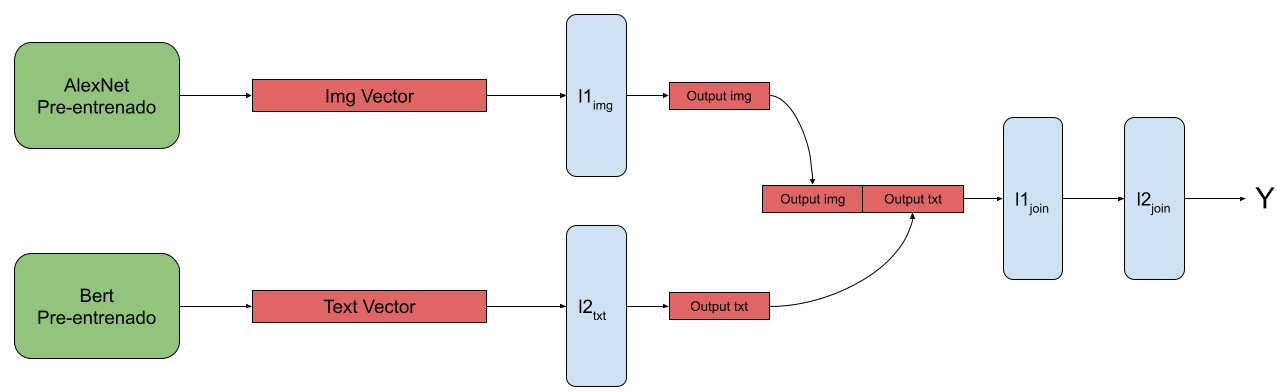

### Baseline

Comparar el funcionamiento de nuestro modelo es fundamental para ver si lo que estamos haciendo funciona bien o mal. En esta ocasión utilizaremos un segundo modelo para poder compararnos. En este solo le entregamos la información de las imágenes a este segundo modelo para realizar la recomendación, esperando que este sea peor que el modelo completo.

In [18]:
class ModelClassImage(torch.nn.Module):
    def __init__(self, pretrained=True, num_classes=117):
        super(ModelClassImage, self).__init__()

        self.l1_img = torch.nn.Linear(4096, 64)
        self.drop = torch.nn.Dropout(0.3)
        self.relu = torch.nn.ReLU(inplace=True)
        self.l2_img = torch.nn.Linear(64, num_classes)

    def forward(self, ids, mask, token_type_ids, img_data, features=False):
        output = self.l1_img(img_data)
        output = self.drop(self.relu(output))
        if features:
            return output
        output = self.l2_img(output)
        return output

## Entrenamiento

Al momento del entrenamiento debemos seleccionar una función de perdida apropiada y un algoritmo de optimización que se comporte bien para este problema.

En este caso al ser un problema de clasificación podemos utilizar la función de pérdida *Cross Entropy*, muy utilizada para este tipo de problemas.

Una alternativa para la función de pérdida podría ser la función *Triplet Loss*, esta busca que el modelo genere representaciones cercanas para elementos de un mismo usuario y genere representaciones más distantes para elementos de usuarios distintos. Un  problema con esa alternativa, es que necesitamos generar triples para el entrenamiento (de ahí su nombre) con elementos de ancla, positivo y negativo para cada iteración en entrenamiento, causando que el proceso sea más complejo, en tiempo y recursos.

Tal como mencionamos en la clase de optimizadores, uno de los algoritmos de optimización en deep learning mas completos y utilizados es Adam, que tiene los beneficios de momentum y la normalización, generando learning rate locales para cada parametros.

Además utilizamos un scheduler en base a la perdida de nuestro set de validación.



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Validating model before training
VAL-Batch 16/16 Loss: 2.3781 Acc: 9.86% 
Epoch N°1
TRAIN-Batch 63/63 Loss: 2.2280 Acc: 16.22% 
VAL-Batch 16/16 Loss: 2.0594 Acc: 29.30% 
Epoch N°2
TRAIN-Batch 63/63 Loss: 2.0399 Acc: 24.36% 
VAL-Batch 16/16 Loss: 1.8550 Acc: 37.01% 
Epoch N°3
TRAIN-Batch 63/63 Loss: 1.8870 Acc: 31.89% 
VAL-Batch 16/16 Loss: 1.7103 Acc: 38.87% 
Epoch N°4
TRAIN-Batch 63/63 Loss: 1.7673 Acc: 35.14% 
VAL-Batch 16/16 Loss: 1.6102 Acc: 41.41% 
Epoch N°5
TRAIN-Batch 63/63 Loss: 1.6505 Acc: 38.91% 
VAL-Batch 16/16 Loss: 1.5143 Acc: 44.14% 


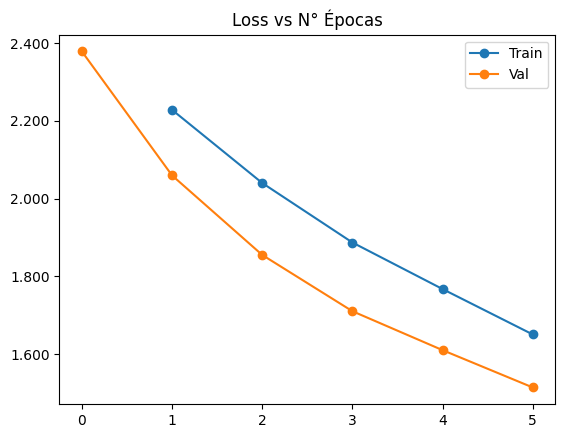

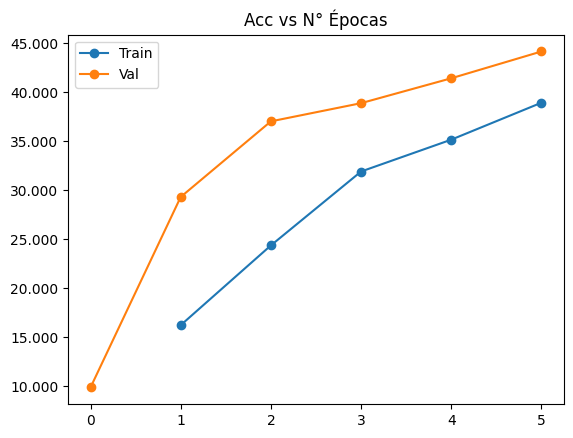

Train Loss: 1.6505 - Train Acc: 38.91%
Val Loss: 1.5143 - Val Acc: 44.14%


In [19]:
from torch import optim
from torch.optim import lr_scheduler
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ModelClass(pretrained=True, num_classes=num_classes)
model.to(device)

criterion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer)

epochs = 5
history = run_training(model, loaders, optimizer, criterion, epochs, scheduler)

print_report(history)

Validating model before training
VAL-Batch 16/16 Loss: 2.7740 Acc: 7.32% 
Epoch N°1
TRAIN-Batch 63/63 Loss: 2.1055 Acc: 23.44% 
VAL-Batch 16/16 Loss: 1.7160 Acc: 38.18% 
Epoch N°2
TRAIN-Batch 63/63 Loss: 1.7172 Acc: 38.52% 
VAL-Batch 16/16 Loss: 1.5995 Acc: 40.04% 
Epoch N°3
TRAIN-Batch 63/63 Loss: 1.5784 Acc: 43.18% 
VAL-Batch 16/16 Loss: 1.5094 Acc: 43.55% 
Epoch N°4
TRAIN-Batch 63/63 Loss: 1.4936 Acc: 45.56% 
VAL-Batch 16/16 Loss: 1.4766 Acc: 44.14% 
Epoch N°5
TRAIN-Batch 63/63 Loss: 1.4295 Acc: 47.97% 
VAL-Batch 16/16 Loss: 1.4450 Acc: 46.19% 


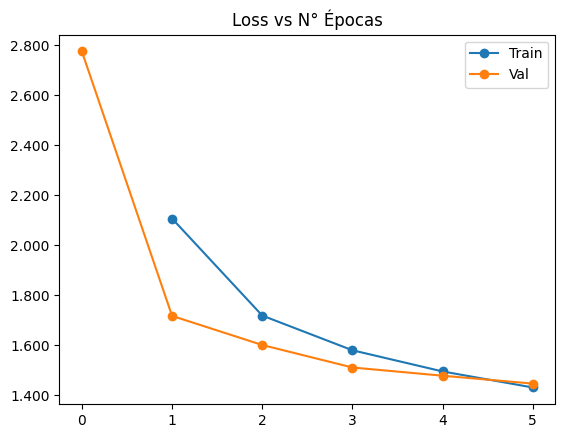

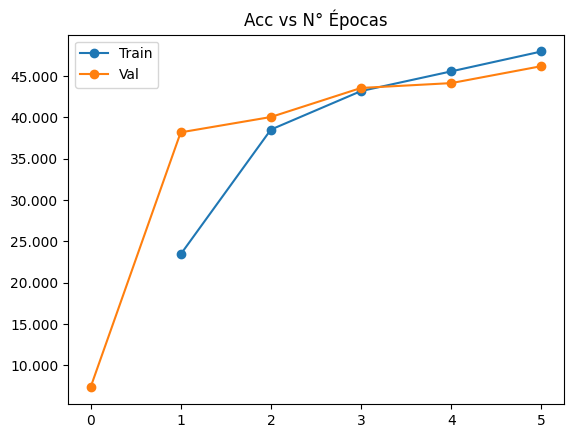

Train Loss: 1.4295 - Train Acc: 47.97%
Val Loss: 1.4450 - Val Acc: 46.19%


In [20]:
from torch import optim
from torch.optim import lr_scheduler
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_img = ModelClassImage(pretrained=True, num_classes=num_classes)
model_img.to(device)

criterion = CrossEntropyLoss()
optimizer = Adam(model_img.parameters(), lr=1e-4) #1e-5
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer)

epochs = 5
history = run_training(model_img, loaders, optimizer, criterion, epochs, scheduler)

print_report(history)

## Actividad 2
1 - Con respecto a los conocimientos adquiridos hasta el momento responda las siguientes preguntas:


- Enumere 2 limitaciones de nuestro modelo. Sugiera una mejora en base a estas limitaciones.

In [21]:
# Actividad 2 - Pregunta 1: Limitaciones del modelo
# ----------------------------------------------------------------
# LIMITACIÓN 1: Problema de "Cold Start" por pocas clases
# El modelo se entrenó solo con 10 de los 117 usuarios disponibles.
# Esto significa que si llega un usuario NUEVO a la plataforma (sin
# historial), el modelo no puede hacer ninguna recomendación para él.
# Además, al usar solo 10 usuarios, el modelo puede no generalizar bien
# a los patrones de gusto de usuarios fuera de esas 10 clases.
#
# LIMITACIÓN 2: Representaciones de imagen congeladas (no adaptadas al dominio)
# Las características de imagen provienen de AlexNet pre-entrenada en ImageNet
# (vectores de 4096 dimensiones que fueron generados fuera del problema).
# Estos vectores son fijos y NO se actualizan durante el entrenamiento de
# nuestro modelo. Por lo tanto, la representación visual no se adapta al
# dominio específico de Pinterest/red social, lo que puede perder información
# relevante para el estilo visual de esta plataforma.
#
# MEJORA PROPUESTA:
# Para resolver la limitación 2, se podría hacer fine-tuning de la red CNN
# completa (no solo usar sus vectores como entrada fija), permitiendo que
# la representación visual se adapte al dominio específico del problema.
# Alternativamente, usar CLIP (Contrastive Language-Image Pretraining) que
# ya fue entrenado para alinear imágenes con texto, sería ideal para este
# tipo de problema multimodal.

Limitacion_1 = 'Cold Start y poca cobertura: el modelo usa solo 10 de 117 usuarios posibles, lo que impide recomendar a usuarios nuevos sin historial y limita la generalización a usuarios fuera del conjunto de entrenamiento' #@param {type:"string"}
Limitacion_2 = 'Representaciones de imagen congeladas: los vectores de imagen provienen de AlexNet pre-entrenada en ImageNet y no se actualizan durante el entrenamiento, por lo que no se adaptan al dominio visual específico de la red social (estilo Pinterest)' #@param {type:"string"}
Mejora = 'Usar fine-tuning completo de una CNN moderna (EfficientNet, ResNet) o CLIP entrenado en pares imagen-texto para generar representaciones visuales que se adapten al dominio específico del problema en lugar de usar vectores fijos de AlexNet' #@param {type:"string"}


- En base a los temas vistos hasta ahora en el diplomado, sugiera una mejora que podría hacerle a este modelo.

In [22]:
# Actividad 2 - Pregunta 2: Mejora basada en el diplomado
# ----------------------------------------------------------------
# Visto en el diplomado: mecanismos de ATENCIÓN (Attention) en Transformers.
#
# CONTEXTO:
# Actualmente el modelo concatena simplemente los vectores de imagen (64 dim)
# y texto (64 dim) y los pasa por capas lineales. Esto trata a imagen y texto
# como igualmente importantes en TODOS los casos.
#
# PROPUESTA DE MEJORA:
# Incorporar mecanismos de Cross-Attention (Atención Cruzada) entre imagen y
# texto. La idea es que el modelo aprenda DINÁMICAMENTE qué partes del texto
# son más relevantes para entender la imagen y viceversa.
#
# EJEMPLO:
# Si el texto dice "beautiful sunset at the beach", el mecanismo de atención
# debería dar más peso a las características visuales de colores cálidos y
# horizontes en lugar de ponderar uniformemente todos los features.
#
# IMPLEMENTACIÓN BÁSICA:
# Se puede usar torch.nn.MultiheadAttention entre las representaciones de
# imagen y texto antes de la capa de clasificación final.
#
# BENEFICIO:
# El modelo captura relaciones semánticas más profundas entre imagen y texto,
# lo que debería mejorar la calidad de los embeddings y por tanto de las
# recomendaciones.

Mejora = 'Incorporar mecanismos de Cross-Attention (Atención Cruzada) entre las representaciones de imagen y texto usando torch.nn.MultiheadAttention, para que el modelo aprenda dinámicamente qué aspectos del texto son más relevantes para entender la imagen y viceversa, en lugar de simplemente concatenar los vectores' #@param {type:"string"}


- Enumere dos formas que se le ocurran de realizar data augmentation con estos datos.

In [23]:
# Actividad 2 - Pregunta 3: Data Augmentation
# ----------------------------------------------------------------
# ¿QUÉ ES DATA AUGMENTATION?
# Es una técnica para AUMENTAR artificialmente el tamaño del dataset
# creando versiones modificadas de los datos originales. Esto ayuda a
# que el modelo generalice mejor y no memorice los ejemplos de entrenamiento.
#
# FORMA 1 - Data Augmentation para TEXTO (Back-Translation):
# Consiste en traducir el texto a otro idioma (ej: inglés → español)
# y luego de vuelta al inglés. El texto resultante es semánticamente
# equivalente pero tiene palabras y estructura diferentes.
# Ejemplo: "A beautiful day at the park" → (español: "Un hermoso día en el parque")
# → de vuelta al inglés: "A lovely day in the park" (ligeramente diferente)
# Esto aumenta la variedad del vocabulario sin cambiar el significado.
#
# FORMA 2 - Data Augmentation para IMÁGENES (Ruido en vectores de features):
# Como trabajamos con vectores de características (no imágenes crudas),
# podemos aplicar pequeñas perturbaciones gaussianas a los vectores.
# Por ejemplo: nuevo_vector = vector_original + N(0, σ²) con σ pequeño.
# También podemos usar Mixup: mezclar dos vectores de la misma clase con
# interpolación lineal: nuevo = α * vector_A + (1-α) * vector_B
# Esto crea representaciones visuales sintéticas que ayudan al modelo
# a ser más robusto frente a pequeñas variaciones.

R_1 = 'Back-Translation para texto: traducir los comentarios a otro idioma (español, francés) y de vuelta al inglés para generar paráfrasis semánticamente equivalentes pero con vocabulario diferente, aumentando la diversidad léxica del dataset de texto' #@param {type:"string"}
R_2 = 'Mixup y ruido gaussiano en vectores de imagen: agregar pequeño ruido N(0, σ²) a los vectores de características de AlexNet, o usar Mixup (interpolación lineal entre vectores de la misma clase) para generar representaciones visuales sintéticas que mejoren la robustez del modelo' #@param {type:"string"}


# Recomendación

Para recomendar contenido a usuarios nos vamos a basar en que usuarios prefieren contenido similar al que ya han interactuado antes. Es decir, imagenes y texto similares a los que a comentado pueden incentivar a generar una nueva interacción.

Una forma que tenemos de verificar si un par imagen-texto es similar a otro es mediante los descriptores que estos tipos de modelos generan para poder realizar la clasificación.



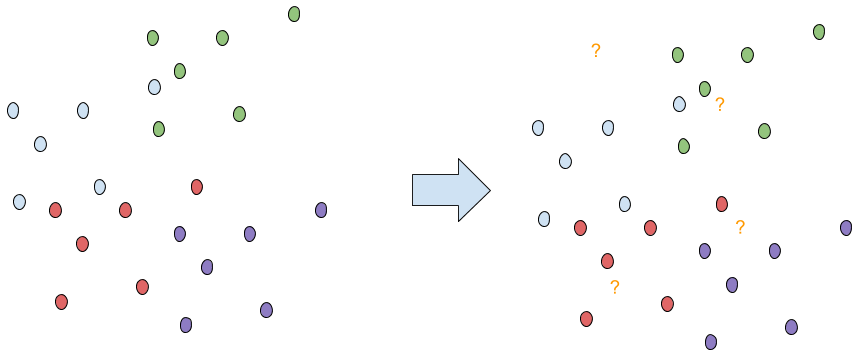

## Obtención de Descriptores

Para obtener una representación que tenga información tanto de la imagen como del texto, utilizamos el parámetro `features` de nuestro modelo. Con esto, en vez de devolvernos las predicciones del modelo, nos entrega un descriptor de nuestro par imagen-texto.

La motivación de esto es la misma que la vista en la clase de finetuning, donde utilizan modelos pre-entrenados para encontrar descriptores de imágenes y luego entrenar un clasificador con estos. La diferencia es que aquí no los vamos a utilizar para entrenar un clasificador sino que lo vamos a utilizar para encontrar distancias entre los diferentes elementos de nuestro dataset.

In [24]:
device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
model.to(device)

test_f = np.zeros((len(testset), 32), dtype=np.float32)
model.eval()
for i, b in enumerate(tqdm(testset)):
    ids = b['text_ids'].to(device, dtype=torch.long).unsqueeze(0)
    mask = b['text_mask'].to(device, dtype=torch.long).unsqueeze(0)
    token_type_ids = b['text_token_type_ids'].to(device, dtype=torch.long).unsqueeze(0)
    img = b['img_data'].to(device, dtype=torch.float).unsqueeze(0)
    targets = b['targets'].to(device, dtype=torch.long).unsqueeze(0)

    test_f[i] = model(ids, mask, token_type_ids, img, features=True).detach().numpy()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [25]:
# Hacer lo mismo que en `f` pero con los datos de train

train_f = np.zeros((len(trainset), 32), dtype=np.float16)
model.eval()
for i, b in enumerate(tqdm(trainset)):
    ids = b['text_ids'].to(device, dtype=torch.long).unsqueeze(0)
    mask = b['text_mask'].to(device, dtype=torch.long).unsqueeze(0)
    token_type_ids = b['text_token_type_ids'].to(device, dtype=torch.long).unsqueeze(0)
    img = b['img_data'].to(device, dtype=torch.float).unsqueeze(0)
    targets = b['targets'].to(device, dtype=torch.long).unsqueeze(0)

    train_f[i] = model(ids, mask, token_type_ids, img, features=True).half().detach().numpy()

  0%|          | 0/4000 [00:00<?, ?it/s]

## Encontrar similares

Una vez que tenemos los descriptores tanto del set de entrenamiento como del set de test podemos comenzar a calcular la distancia de los nuevos datos (test) con respecto a los utilizado durante el entrenamiento (train).

La intuicion de esto es que queremos recomendar los nuevos elementos a usuarios con gustos similares, y para esto nos basamos en alguna metrica de distancia entre ambos descriptores. Al encontrar la distancia menor de un elementos con otro sabemos a que usuario recomendarle esta nueva imagen, ya que conocemos el usuario que escribio el comentario en esa imagen en los datos de entrenamiento.

In [26]:
from sklearn.metrics import pairwise_distances
import heapq
import textwrap


def find_similar_images(embedding, query_id=None, metrics=('euclidean',), topk=5):
    assert len(metrics) > 0
    assert topk <= 30 # to avoid requesting too many images
    n = embedding.shape[0]
    if query_id is None:
        query_id = np.random.randint(n)
    results = {}
    # --- show retrieved images for each metric
    for metric in metrics:
        #print('-------- retrieved with metric = %s -----' % metric)
        distances = pairwise_distances(embedding[query_id].reshape(1,-1), embedding, metric=metric)
        heap = []
        for i in range(n):
            if i == query_id:
                continue
            if len(heap) < topk:
                heapq.heappush(heap, (-distances[0][i], i))
            else:
                heapq.heappushpop(heap, (-distances[0][i], i))
        heap.sort(reverse=True)
        results[metric] = tuple(zip(*heap))
        results[metric] = (list(results[metric][1]), [-float(dist) for dist in results[metric][0]])
    return results

def display_item_text(dataset, item_ids):
  """Displays the text for a list of item IDs with improved formatting and wrapping."""
  for i, item_id in enumerate(item_ids):
    print((f"----- Recommended Item {i+1} " + "-----"*60)[:60])
    print()
    wrapped_text = textwrap.fill(dataset.txt_data[item_id], width=60) # Wrap text at 80 characters
    print(wrapped_text)
    print()
    print("-" * 60) # Add a separator line


In [27]:
query_id = 2
find_similar_images(test_f, metrics=('cosine','euclidean'), query_id=query_id, topk=10)

{'cosine': ([593, 557, 594, 879, 96, 79, 525, 86, 506, 576],
  [0.02356278896331787,
   0.0239412784576416,
   0.02674335241317749,
   0.028798818588256836,
   0.029377341270446777,
   0.033729493618011475,
   0.037842631340026855,
   0.03888827562332153,
   0.039067089557647705,
   0.03923439979553223]),
 'euclidean': ([594, 593, 79, 506, 543, 96, 723, 557, 86, 423],
  [2.247223138809204,
   2.306626558303833,
   2.374553680419922,
   2.548906087875366,
   2.5658068656921387,
   2.5970137119293213,
   2.632082939147949,
   2.7225000858306885,
   2.7819976806640625,
   2.785848379135132])}

In [28]:
# Exploración: Probar find_similar_images con diferentes consultas y mostrar textos
# ----------------------------------------------------------------
# Esta celda sirve para EXPERIMENTAR con el sistema de búsqueda de similares.
# Podemos cambiar query_id para ver qué contenido recomienda el modelo
# para diferentes publicaciones del conjunto de test.

# Probamos con un query_id diferente para comparar resultados
query_id_2 = 5  # Puedes cambiar este número para explorar diferentes consultas

print(f"=== Publicación CONSULTA (ID={query_id_2}) ===")
print(f"Texto: {testset.txt_data[query_id_2]}")
print()

# Encontramos los 5 más similares usando distancia coseno
resultados = find_similar_images(test_f, metrics=('cosine',), query_id=query_id_2, topk=5)

# Mostramos los textos de los ítems más similares
print(f"=== Top-5 ítems más similares (distancia coseno) ===")
items_similares = resultados['cosine'][0]  # lista de índices de los más cercanos
display_item_text(testset, items_similares)

# NOTA CONCEPTUAL:
# La distancia COSENO mide el ángulo entre dos vectores (ignora la magnitud).
# Dos vectores con distancia coseno ≈ 0 son muy similares (apuntan en la
# misma dirección en el espacio de representación).
# La distancia EUCLIDIANA mide la distancia "recta" entre dos puntos.
# Para embeddings normalizados, ambas métricas suelen dar resultados similares.
print("\nNOTA: Si los textos recomendados son semánticamente similares al query,")
print("significa que el modelo aprendió buenas representaciones de contenido.")


=== Publicación CONSULTA (ID=5) ===
Texto: d portrait wish i knew who it was so i could give them credit

=== Top-5 ítems más similares (distancia coseno) ===
----- Recommended Item 1 -----------------------------------

wise words of nicholas

------------------------------------------------------------
----- Recommended Item 2 -----------------------------------

work work work

------------------------------------------------------------
----- Recommended Item 3 -----------------------------------

winnie the pooh

------------------------------------------------------------
----- Recommended Item 4 -----------------------------------

wow

------------------------------------------------------------
----- Recommended Item 5 -----------------------------------

rules for a good relationship

------------------------------------------------------------

NOTA: Si los textos recomendados son semánticamente similares al query,
significa que el modelo aprendió buenas representaciones de 

## Recomendación

Tal como se menciono en la sección anterior, con las distancias entre los vectores podemos recomendar nuevo contenido a un usuario, considerando las distancias minimas entre estos.

In [29]:
targets = np.array(testset.targets)
n_targets = len(set(targets))

In [30]:
# Creo diccionarios con user_id => feats (los features concatenados de todos los items del usuario en train)
# y lo transformo a un np.array (user_repr)
from collections import defaultdict

user_dict = {}
for user_id, features in zip(trainset.targets, train_f):
    if not user_id in user_dict:
        user_dict[user_id] = []
    user_dict[user_id].append(features)

for user_id in user_dict:
    user_dict[user_id] = np.array(user_dict[user_id])

user_repr = np.array([user_dict[user_id] for user_id in range(n_targets)])

In [31]:
# Calculo los scores para cada imágen en test con respecto a un usuario
metric = 'cosine'

n_users, n_images, _ = user_repr.shape
user_repr = user_repr.reshape(-1, 32)
dists = pairwise_distances(user_repr, test_f, metric=metric)
dists = dists.reshape(n_users, n_images, -1)
scores = dists.min(axis=1)

print(scores.shape)

(10, 1000)


In [32]:
# Lista de recomendación
k = 10
recommendation_list = np.argpartition(scores, k)
recommendation_list = recommendation_list[:,:k]

En esta lista se muestra el id de los elementos de nuestro base de datos (imagen-texto) que le podria interesar a 10 usuarios diferentes, en base a las menores distancias de los elementos que conocemos del usuario con cada uno de los nuevos elementos que nos llegaron.

In [33]:
recommendation_list

array([[ 79, 541,  47, 432, 782, 675, 763,  36, 597, 565],
       [940, 898, 932, 946, 262, 160, 960, 892, 122, 131],
       [292, 661, 265, 225, 782, 675, 677, 660, 269, 253],
       [379, 321, 390, 353, 358, 357, 376, 122, 191, 380],
       [432, 479, 465,  41, 422, 424, 716, 580, 407, 426],
       [440, 570,  41, 246, 757, 552, 269, 695,  49, 535],
       [693, 206, 673, 660, 268, 647, 697, 763, 267, 217],
       [745,  74,  41, 267, 757, 705, 714, 716, 763,  76],
       [817, 853, 823, 993, 989, 198, 161, 158, 826, 100],
       [906, 950, 154, 994, 910, 158, 959, 980, 987, 989]])

In [34]:
user_id_to_display = 0

# Muestra el texto de los artículos recomendados para el usuario seleccionado.
recommended_item_ids = recommendation_list[user_id_to_display]
query_id = recommended_item_ids[user_id_to_display] # Using the first recommended item as a placeholder query

# Muestra el texto del elemento consultado.
print(f"Query item text for user {user_id_to_display}:")
print()
wrapped_query_text = textwrap.fill(testset.txt_data[query_id], width=60)
print(wrapped_query_text)
print()

print(f"\nRecommended items for user {user_id_to_display}:\n")
display_item_text(testset, recommended_item_ids)

Query item text for user 0:

i don t like transparent storage boxes but they re the most
functional ones you can find in ikea so this is a great way
to cover the mess in the boxes


Recommended items for user 0:

----- Recommended Item 1 -----------------------------------

i don t like transparent storage boxes but they re the most
functional ones you can find in ikea so this is a great way
to cover the mess in the boxes

------------------------------------------------------------
----- Recommended Item 2 -----------------------------------

moulin rouge

------------------------------------------------------------
----- Recommended Item 3 -----------------------------------

curtain rods hung from the ceiling to simulate a canopy bed
love

------------------------------------------------------------
----- Recommended Item 4 -----------------------------------

a ton of free vintage embroidery patterns

------------------------------------------------------------
----- Recommended It

## Métricas de Comparación

Tal como vimos en clases, existen varias métricas que se pueden utilizar para comprobar el correcto funcionamiento de nuestro modelo de recomendación.

Las primeras métricas son *Precision* y *Recall*, que nos entregan la cantidad de datos correctos recuperamos y estamos recuperando, respectivamente. La siguiente figura nos puede ayudar a entender estos conceptos.

<figure>
<center>
<img src='https://upload.wikimedia.org/wikipedia/commons/2/26/Precisionrecall.svg' height="500" />
<figcaption>Cálculo de precision y recall.</figcaption>
</center>

</figure>

La *Precision* nos dice la cantidad de elementos correctos que recuperamos en nuestro set, es decir, de los elementos que recomendamos al usuario, cuantos de estos efectivamente pueden gustarle a la persona.

> $Precision = \frac{True Positive}{True Positive + False Positive} $

Por otro lado, el *Recall* nos indica la cantidad de elementos relevantes que le estamos mostrando al usuario del total de elementos relevantes que sabemos le pueden gustar. Es decir, del total de elementos relevantes para el usuario que tenemos en nuestra base de datos, cuantos de estos los estamos mostrando en nuestra recomendación.

> $Recall = \frac{True Positive}{True Positive + False Negative} $

Una métrica particular para sistemas recomendadores es Normalized Discounted Cumulative Gain (nDCG), que busca entregar una metrica con respecto al ránking que le estamos entregando. La intuición es que los elementos mas relevantes debería aparecer primero en nuestro ránking para ir disminuyendo en relevancia.

> $nDCG_p = \frac{\sum_{i=1}^p\frac{2^{rel_i}-1}{log_2(i+1)}}{\sum_{i=1}^{REL_p}\frac{2^{rel_i}-1}{log_2(i+1)}} = \frac{DCG_p}{IDCG_p}$

En nuestro caso, todos los elementos que queremos recomendarle al usuario tienen igual relevancia (1) y los otros tienen relevancia cero (0).

In [35]:
from sklearn.metrics import ndcg_score

def ndcg(scores, targets, k):
    relevance = np.zeros((targets.size, targets.max() + 1))
    relevance[np.arange(targets.size), targets] = 1
    relevance = relevance.T

    return ndcg_score(relevance, scores, k=k)

def pr_at_k(scores, targets, k):
    recs = np.argpartition(scores, k)
    recs = recs[:,:k]
    n_targets = len(set(targets))
    rels = np.array([np.where(targets == user_id)[0] for user_id in range(n_targets)])

    precision = []
    recall = []
    for user_id, (recommended, relevants) in enumerate(zip(recs, rels)):
        recommended = recommended[:k]
        recommended = set(recommended)
        relevants = set(relevants)
        p = len(recommended & relevants) / len(recommended)
        r = len(recommended & relevants) / len(relevants)
        precision.append(p)
        recall.append(r)

    return np.mean(p), np.mean(r) # P@k, R@k

In [36]:
pr, rec = pr_at_k(scores, targets, k=400)
obtained_ndcg = ndcg(scores, targets, k=400)
print(f'P={pr}')
print(f'R={rec}')
print(f'nDCG={obtained_ndcg}')

P=0.235
R=0.94
nDCG=0.06816503862423026


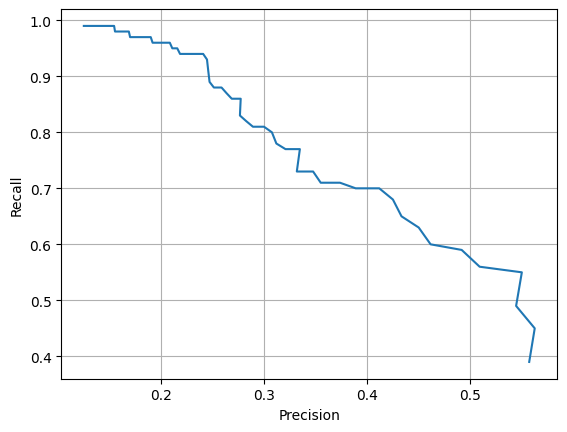

In [37]:
pr_all = []
rec_all = []
ndcg_all = []
for i in range(70,800, 10):
    pr, rec = pr_at_k(scores, targets, k=i)
    pr_all.append(pr)
    rec_all.append(rec)
    o_ndcg = ndcg(scores, targets, k=i)
    ndcg_all.append(o_ndcg)

fig, ax = plt.subplots()
ax.plot(pr_all, rec_all)

ax.set(xlabel='Precision', ylabel='Recall')
ax.grid()

plt.show()

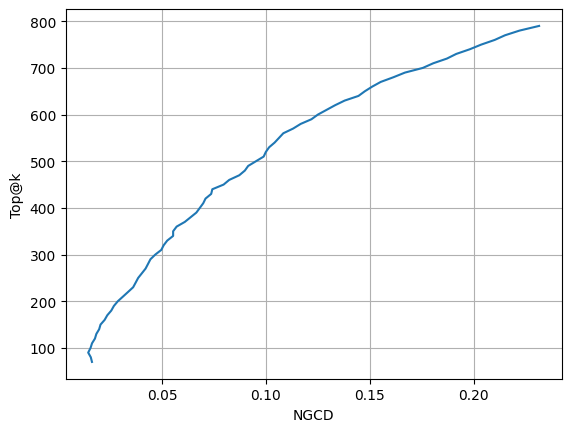

In [38]:
fig, ax = plt.subplots()
ax.plot(ndcg_all, list(range(70, 800, 10)))

ax.set(xlabel='NGCD', ylabel='Top@k')
ax.grid()

plt.show()

## Actividad 3


1. A parte del rendimiento del sistema recomendador, ¿qué otros aspectos le parece importante medir en un sistema como el desarrollado? De uno o dos y brevemente describa (1-3 frases) por qué es relevante.

In [39]:
# Actividad 3 - Pregunta 1: Otros aspectos importantes a medir
# ----------------------------------------------------------------
# CONTEXTO:
# Precision@k, Recall@k y nDCG miden QUÉ TAN CORRECTAS son las recomendaciones,
# pero un buen sistema recomendador también debe considerar otros aspectos
# que afectan la experiencia del usuario.
#
# ASPECTO 1 - DIVERSIDAD de las recomendaciones:
# Un sistema que siempre recomienda el mismo tipo de contenido puede ser
# "preciso" pero aburrido. Si un usuario que le gustan los perros siempre
# recibe fotos de perros, nunca descubrirá que también le podrían gustar
# los gatos. Esto se conoce como "burbuja de filtro" (filter bubble).
# La diversidad se puede medir calculando la distancia promedio entre los
# embeddings de los ítems recomendados (Intra-List Diversity, ILD).
#
# ASPECTO 2 - NOVEDAD del contenido:
# Las recomendaciones deben incluir contenido que el usuario NO haya visto
# antes. Si el modelo recomienda constantemente publicaciones que el usuario
# ya vio, no agrega valor. La novedad mide qué tan "nuevo" o inesperado es
# el contenido recomendado para ese usuario en particular.
#
# ¿POR QUÉ SON RELEVANTES?
# Un sistema que optimiza solo la precisión puede volverse redundante y
# disminuir el engagement a largo plazo. La diversidad y novedad son
# fundamentales para mantener a los usuarios activos en la plataforma,
# que es el objetivo real de un sistema de recomendación comercial.

R = "Diversidad de las recomendaciones (evitar la burbuja de filtro) y Novedad del contenido (no recomendar lo que el usuario ya vio)" #@param {type:"string"}
Por_que = "Solo optimizar precisión genera sistemas que recomiendan siempre lo mismo (burbuja de filtro), reduciendo el engagement a largo plazo. La diversidad asegura que el usuario descubra contenido variado y la novedad evita recomendar publicaciones que ya vio, ambas son fundamentales para la satisfacción real del usuario en una red social." #@param {type:"string"}


2. ¿Qué métrica, diferentes de las mencionadas en clases, le podría servir para medir estos aspectos en su modelo?
Enumere una o dos métricas.

In [40]:
# Actividad 3 - Pregunta 2: Métricas adicionales para medir diversidad y novedad
# ----------------------------------------------------------------
# CONCEPTO BASE:
# Necesitamos métricas que vayan más allá de "¿acerté o no acerté?" y que
# capturen la CALIDAD de la experiencia de recomendación completa.
#
# MÉTRICA 1 - Mean Average Precision (MAP):
# A diferencia de P@k que solo cuenta cuántos son relevantes en el top-k,
# MAP considera el ORDEN en que aparecen los ítems relevantes.
# Si los ítems relevantes aparecen al principio de la lista → MAP alto.
# Si los ítems relevantes aparecen al final → MAP bajo (aunque la precisión
# total sea igual). Esto es importante porque los usuarios raramente miran
# más allá de los primeros ítems recomendados.
#
# Fórmula simplificada:
# MAP = promedio de la Average Precision de cada usuario
# AP = suma de (Precision@k × relevancia_k) / total de ítems relevantes
#
# MÉTRICA 2 - Intra-List Diversity (ILD):
# Mide la DIVERSIDAD dentro de las recomendaciones calculando la distancia
# promedio entre todos los pares de ítems en la lista recomendada.
# ILD = (2 / k(k-1)) × Σ dist(i, j) para todos los pares i≠j en la lista
# Donde dist() puede ser distancia coseno entre embeddings.
# ILD alto → recomendaciones diversas (distintos temas/estilos)
# ILD bajo → recomendaciones redundantes (todo muy similar)
#
# BENEFICIO: ILD captura directamente el problema de "burbuja de filtro"
# que las métricas de precisión no detectan.

R_1 = "Mean Average Precision (MAP): considera el orden de los ítems relevantes en la lista, no solo si aparecen, penalizando cuando los ítems relevantes aparecen al final de las recomendaciones. Es más informativa que P@k porque refleja que los usuarios solo miran los primeros resultados." #@param {type:"string"}
R_2 = "Intra-List Diversity (ILD): calcula la distancia coseno promedio entre todos los pares de embeddings de los ítems recomendados. Un ILD alto indica recomendaciones diversas (diferentes temas/estilos), ayudando a detectar y prevenir la burbuja de filtro que las métricas de precisión no capturan." #@param {type:"string"}
